In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()

print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)

print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

In [2]:
ts = df["Avg_Yield_Total"]
ts.tail()

Date
2023-04-01    4128
2023-09-01    3877
2024-04-01    4599
2024-09-01    3914
2025-04-01    4760
Name: Avg_Yield_Total, dtype: int64

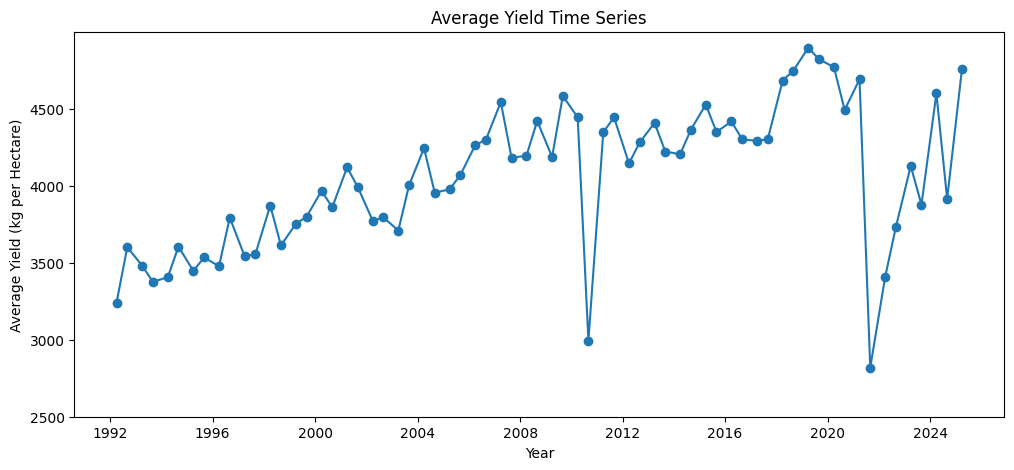

In [6]:
plt.figure(figsize=(12,5))
plt.plot(ts,marker="o")

plt.title("Average Yield Time Series")
plt.xlabel("Year")
plt.ylabel("Average Yield (kg per Hectare)")
plt.ylim(2500,)
plt.show()

In [4]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [7]:
from statsmodels.tsa.stattools import adfuller, kpss
def adf_test(series, label="Series"):
    result = adfuller(series, autolag="AIC")
    p = result[1]
    print(f"\n  ADF Test [{label}]")
    print(f"    Statistic : {result[0]:.4f}")
    print(f"    p-value   : {p:.4f}")
    print(f"    Critical 5%: {result[4]['5%']:.4f}")
    print(f"    → {'✅ STATIONARY' if p < 0.05 else '❌ NON-STATIONARY — differencing needed'}")
    return p

adf_test(ts, "Original")


  ADF Test [Original]
    Statistic : -2.8805
    p-value   : 0.0477
    Critical 5%: -2.9072
    → ✅ STATIONARY


np.float64(0.047656983940750845)

In [10]:
# Automatically Find Best SARIMA Model
auto_model = auto_arima(train, 
                   seasonal=False,
                #    test='adf', 
                #    m=2, 
                   stepwise=True, 
                   suppress_warnings=True,
                   trace=True)



Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=731.004, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=756.096, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=749.409, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=754.453, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=730.013, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=735.850, Time=0.02 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=736.211, Time=0.05 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=734.350, Time=0.04 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0] intercept
Total fit time: 0.993 seconds


In [13]:
# Generate a summary of the best model found
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   53
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -360.006
Date:                Sat, 23 May 2026   AIC                            730.013
Time:                        14:07:46   BIC                            739.769
Sample:                             0   HQIC                           733.753
                                 - 53                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     28.3355     14.225      1.992      0.046       0.455      56.216
ar.L1         -0.0936      0.385     -0.243      0.808      -0.848       0.661
ar.L2         -0.2604      0.282     -0.925      0.3

In [14]:
print(auto_model.fit(train))

 ARIMA(2,1,1)(0,0,0)[0] intercept


In [15]:
forecast = auto_model.predict(n_periods=len(test))
forecast

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    4506.083030
54    4451.762485
55    4531.256833
56    4566.295703
57    4570.648624
58    4589.451745
59    4614.893192
60    4635.949972
61    4655.688519
62    4676.692348
63    4697.921008
64    4718.799110
65    4739.651485
66    4760.597560
dtype: float64

In [16]:
forecast_df = pd.DataFrame(forecast.values.round(2), index= test.index, columns=['Prediction'])
forecast_df

,Prediction
Date,
2018-09-01,4506.08
2019-04-01,4451.76
2019-09-01,4531.26
2020-04-01,4566.30
2020-09-01,4570.65
2021-04-01,4589.45
2021-09-01,4614.89
2022-04-01,4635.95
2022-09-01,4655.69


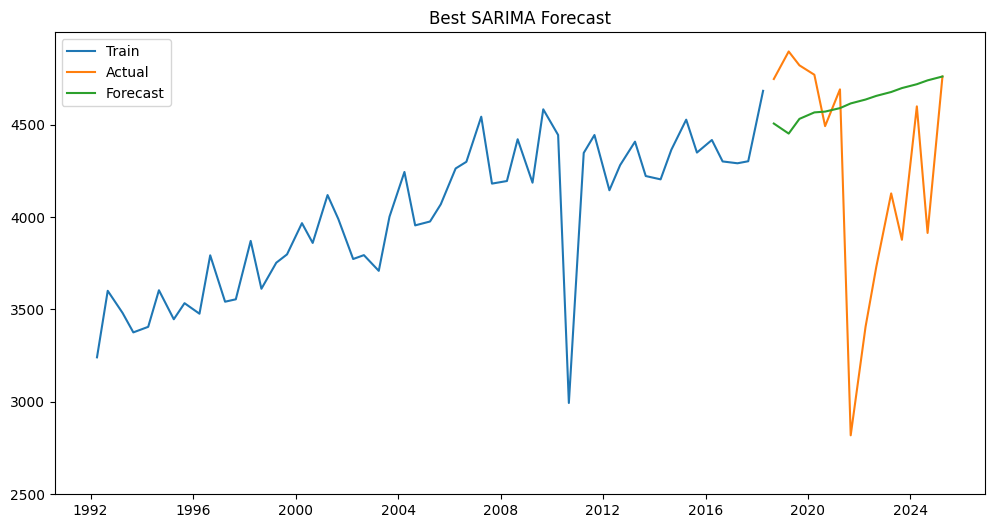

In [21]:
#Plot Forecast
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train')

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, forecast, label='Forecast')

plt.legend()

plt.title("Best SARIMA Forecast")

plt.ylim(2500,)

plt.show()

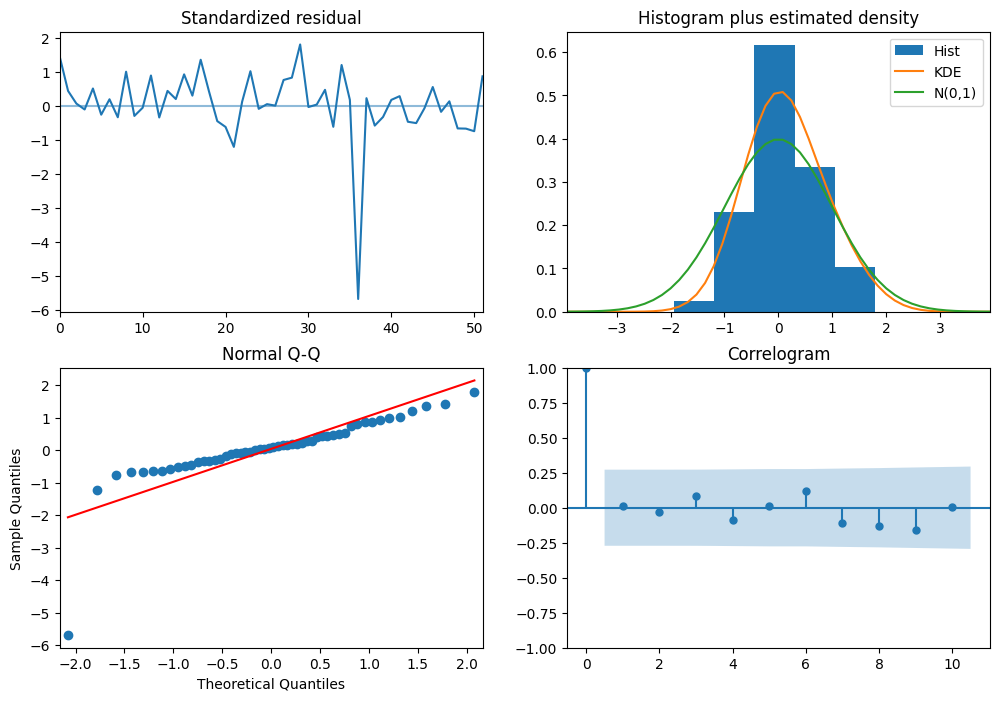

In [19]:
# Diagnostic plots
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [20]:
#Evaluate Model
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print("RMSE :", rmse)
print("MAPE :", mape)

RMSE : 739.6407696989024
MAPE : 15.077510786900863
